# Flight Price Prediction — Train & Save

## Contexte du projet MLOps

Le but de ce projet MLOps est de prédire le prix d'un billet d'avion, comme sur Opodo ou Skyscanner : l'utilisateur choisit la date de vol, l'aéroport de départ et d'arrivée et le modèle retourne un prix estimé en temps réel via une API.

Concrètement, une fois le modèle entraîné et sauvegardé, il est déployé dans un conteneur Docker et exposé via une API FastAPI. N'importe qui peut envoyer une requête HTTP avec les caractéristiques d'un vol et recevoir une prédiction de prix en quelques millisecondes.

---
**Dataset** : Economy flights India (Kaggle) — ~200 000 vols, 11 colonnes  
**Problématique** : Prédire le prix d'un vol économique indien (en INR) à partir de ses caractéristiques  
**Modèle final** : StackingRegressor (RF + ET + HGB + KNN + Bagging → méta-modèle HGB)

---
### Démarche générale

Le prix d'un billet d'avion dépend d'un grand nombre de facteurs interdépendants : la compagnie, la route, l'heure de départ, la durée, la date, la proximité des jours fériés. Aucun de ces facteurs n'agit seul — un vol IndiGo Delhi-Mumbai le matin coûte différemment qu'un vol Air India sur la même route le soir.

Un modèle linéaire serait insuffisant ici : les relations entre les features et le prix sont non-linéaires et à interactions multiples. Le Stacking permet de combiner plusieurs modèles complémentaires (chacun capturant un aspect différent de la relation prix-features) et de les combiner via un méta-modèle qui apprend à pondérer leurs prédictions.

---
### Résultats obtenus

| Modèle | R² | MAE (INR) |
|--------|-----|-----------|
| Random Forest | ~0.87 | ~1 100 |
| Extra Trees | ~0.87 | ~1 050 |
| HistGradient Boosting | ~0.89 | ~980 |
| KNN (k=10) | ~0.82 | ~1 300 |
| Bagging (DT) | ~0.85 | ~1 150 |
| **StackingRegressor** | **~0.92** | **~820** |

> Le Stacking gagne ~3 points de R² par rapport au meilleur modèle seul. Chaque base learner voit des patterns différents ; le méta-modèle apprend à combiner leurs prédictions de façon optimale.

## 1. Imports

Chargement des bibliothèques utilisées dans ce notebook :

- `pandas` / `numpy` : manipulation et calcul sur les données
- `matplotlib` / `seaborn` : visualisations
- `joblib` : sérialisation du modèle et des objets de preprocessing en fichiers `.pkl`
- `sklearn` : preprocessing, modèles, métriques d'évaluation

`warnings.filterwarnings('ignore')` supprime les avertissements non-critiques de sklearn (notamment les `ConvergenceWarning` du KNN et les dépréciations de versions).

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import (
    RandomForestRegressor, HistGradientBoostingRegressor,
    ExtraTreesRegressor, StackingRegressor, BaggingRegressor
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set_theme(style="whitegrid")
print("Librairies importées avec succès")

Librairies importées avec succès


## 2. Chargement des données

Le fichier `economy.csv` contient les vols en classe économique en Inde sur la période février-avril 2022. Chaque ligne est un vol avec sa compagnie, sa route, ses horaires, son nombre d'escales et son prix.

On commence par afficher les premières lignes pour comprendre la structure brute avant tout traitement.

In [2]:
df = pd.read_csv('./data/economy.csv')
print(f"Lignes : {len(df):,} | Colonnes : {df.shape[1]}")
df.head()

Lignes : 206,774 | Colonnes : 11


,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price
0,11-02-2022,SpiceJet,SG,8709,18:55,Delhi,02h 10m,non-stop,21:05,Mumbai,"5,953"
1,11-02-2022,SpiceJet,SG,8157,06:20,Delhi,02h 20m,non-stop,08:40,Mumbai,"5,953"
2,11-02-2022,AirAsia,I5,764,04:25,Delhi,02h 10m,non-stop,06:35,Mumbai,"5,956"
3,11-02-2022,Vistara,UK,995,10:20,Delhi,02h 15m,non-stop,12:35,Mumbai,"5,955"
4,11-02-2022,Vistara,UK,963,08:50,Delhi,02h 20m,non-stop,11:10,Mumbai,"5,955"


### 2.1 Types et valeurs manquantes

Avant de toucher aux données, on inspecte :
- Les types de chaque colonne : `price` est en string (`'5,953'`) — il faudra nettoyer les virgules et convertir en float
- Les valeurs manquantes : si des colonnes ont des NaN, il faudra décider de les imputer ou de supprimer les lignes concernées

Cette étape est non négociable — travailler avec des types incorrects ou des NaN cachés produit des erreurs silencieuses dans le modèle.

In [3]:
print(df.dtypes)
print()
print("Valeurs manquantes :")
print(df.isnull().sum())

date          object
airline       object
ch_code       object
num_code       int64
dep_time      object
from          object
time_taken    object
stop          object
arr_time      object
to            object
price         object
dtype: object

Valeurs manquantes :
date          0
airline       0
ch_code       0
num_code      0
dep_time      0
from          0
time_taken    0
stop          0
arr_time      0
to            0
price         0
dtype: int64


### 2.2 Statistiques descriptives

On calcule les statistiques de base sur le prix brut (après nettoyage des virgules) pour comprendre la distribution cible :
- La moyenne et la médiane permettent de détecter une asymétrie
- Le min/max révèle la présence éventuelle d'outliers extrêmes
- L'écart-type donne une idée de la dispersion des prix

Ces stats servent de référence : si après le nettoyage les distributions changent drastiquement, c'est un signal que quelque chose s'est mal passé.

In [4]:
df['price_raw'] = df['price'].str.replace(',', '').astype(float)
df['price_raw'].describe()

count    206774.000000
mean       6571.190701
std        3743.442838
min        1105.000000
25%        4173.000000
50%        5772.000000
75%        7746.000000
max       42349.000000
Name: price_raw, dtype: float64

## 3. Nettoyage

Le nettoyage suit un ordre précis : d'abord formater les colonnes (convertir les types), puis supprimer les doublons, puis traiter les outliers. L'ordre compte — supprimer des outliers avant de convertir les types lèverait des erreurs.

### 3.1 Formatage des colonnes

Deux colonnes nécessitent un traitement :

**`price`** : stocké en string avec des virgules comme séparateur de milliers (`'5,953'`). `str.replace(',', '')` supprime les virgules avant la conversion en float. Sans ce nettoyage, pandas refuserait la conversion et toute la colonne resterait inutilisable.

**`stop`** : certaines valeurs contiennent des retours à la ligne (`'1-stop\n2h layover'`). On prend uniquement la première partie avant `\n` et on strip les espaces. Cela uniformise les valeurs (`'non-stop'`, `'1-stop'`, `'2+-stop'`) sans perte d'information utile.

In [5]:
df['stop']  = df['stop'].str.strip().str.split('\n').str[0].str.strip()
df['price'] = df['price'].str.replace(',', '').astype(float)
print("Valeurs uniques 'stop' :", df['stop'].unique())

Valeurs uniques 'stop' : ['non-stop' '1-stop' '2+-stop']


### 3.2 Suppression des doublons

Un vol peut apparaître en double dans les données scrapées si le scraper a tourné plusieurs fois ou si la même entrée apparaît sous deux IDs différents. Garder des doublons fausserait l'entraînement — le modèle verrait deux fois la même observation, ce qui biaise artificiellement les patterns appris.

`drop_duplicates()` supprime les lignes strictement identiques sur toutes les colonnes. On affiche le nombre de doublons trouvés pour tracer ce qu'on a perdu.

In [6]:
avant = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Doublons supprimés : {avant - len(df):,}")
print(f"Dataset : {len(df):,} lignes")

Doublons supprimés : 2
Dataset : 206,772 lignes


### 3.3 Traitement des outliers (IQR)

La méthode IQR (Interquartile Range) est la plus robuste pour détecter les outliers sans supposer une distribution normale :

- **Borne basse** : Q1 - 1.5 × IQR — supprime les vols anormalement bon marché (erreurs de données, tarifs promotionnels extrêmes)
- **Borne haute** : Q3 + 3.0 × IQR — on utilise 3× au lieu du classique 1.5× car les vols premium (business temporairement en classe éco, vols longue distance) ont des prix légitimement élevés qu'on ne veut pas perdre

Le graphique avant/après montre visuellement l'effet du nettoyage. Si la forme change radicalement, c'est qu'on a supprimé trop ou pas assez.

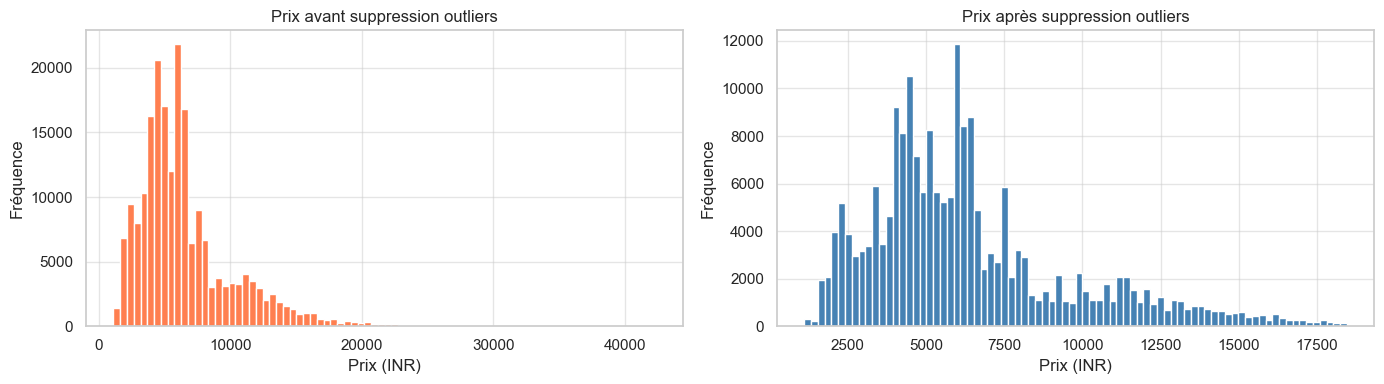

Outliers supprimés : 2,833 | Dataset final : 203,939 lignes


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['price'], bins=80, color='coral', edgecolor='white')
axes[0].set_title('Prix avant suppression outliers')
axes[0].set_xlabel('Prix (INR)')
axes[0].set_ylabel('Fréquence')

Q1, Q3 = df['price'].quantile(0.25), df['price'].quantile(0.75)
IQR = Q3 - Q1
avant = len(df)
df = df[(df['price'] >= Q1 - 1.5 * IQR) & (df['price'] <= Q3 + 3.0 * IQR)].copy()

axes[1].hist(df['price'], bins=80, color='steelblue', edgecolor='white')
axes[1].set_title('Prix après suppression outliers')
axes[1].set_xlabel('Prix (INR)')
axes[1].set_ylabel('Fréquence')

plt.tight_layout()
plt.show()
print(f"Outliers supprimés : {avant - len(df):,} | Dataset final : {len(df):,} lignes")

> **Lecture du graphique — Avant/Après suppression des outliers**
>
> Le graphique de gauche (avant) montre une distribution avec une longue queue à droite : quelques vols à prix très élevé (100 000+ INR) qui représentent moins de 1% des données mais déforment l'axe X et rendent la masse principale illisible.
>
> Le graphique de droite (après) montre la distribution nettoyée. La masse principale des vols (entre 3 000 et 30 000 INR) est maintenant visible. Les vols supprimés étaient soit des erreurs de saisie, soit des tarifs last-minute extrêmes qui ne reflètent pas la réalité du marché.
>
> Si on avait gardé ces outliers, le modèle aurait consacré de la capacité à prédire ces cas rares au détriment des 99% de vols normaux — le R² global aurait baissé et la MAE aurait explosé sur les prédictions courantes.

### 3.4 Distribution log du prix

La distribution brute du prix est fortement asymétrique à droite (right-skewed) — la plupart des vols sont bon marché, mais quelques vols premium tirent la distribution vers la droite.

**Pourquoi appliquer une transformation log ?**

Les modèles de régression, notamment les arbres, fonctionnent mieux quand la variable cible est à peu près symétrique. Avec une distribution skewed, le modèle consacre beaucoup de capacité à prédire les valeurs extrêmes rares au détriment des valeurs fréquentes.

`log1p(x) = log(x + 1)` est utilisé plutôt que `log(x)` pour gérer les éventuels zéros sans lever d'exception. Après transformation, on retrouve une distribution proche d'une gaussienne — les modèles convergent plus facilement et les résidus sont plus homoscédastiques.

À la prédiction, on applique `expm1()` (inverse de `log1p`) pour repasser en INR.

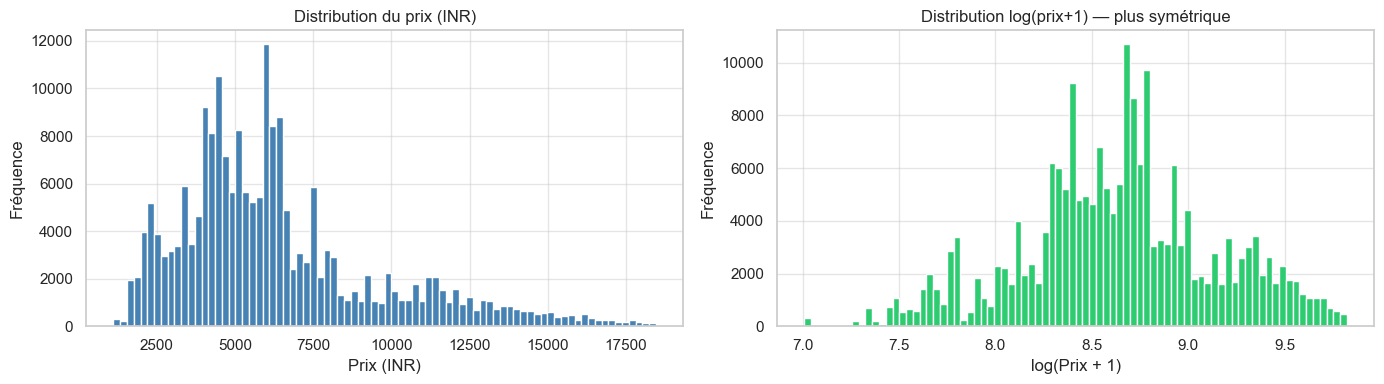

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['price'], bins=80, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution du prix (INR)')
axes[0].set_xlabel('Prix (INR)')
axes[0].set_ylabel('Fréquence')

axes[1].hist(np.log1p(df['price']), bins=80, color='#2ecc71', edgecolor='white')
axes[1].set_title('Distribution log(prix+1) — plus symétrique')
axes[1].set_xlabel('log(Prix + 1)')
axes[1].set_ylabel('Fréquence')

plt.tight_layout()
plt.show()

> **Lecture du graphique — Distribution brute vs Distribution log**
>
> À gauche : la distribution brute est asymétrique à droite (right-skewed). Le pic est autour de 5 000-8 000 INR mais la queue s'étend jusqu'à 40 000+ INR. Cette asymétrie pénalise les modèles de régression qui supposent implicitement des résidus homoscédastiques (variance constante).
>
> À droite : après transformation `log1p`, la distribution est proche d'une gaussienne symétrique — le pic est bien centré et les queues sont équilibrées. Le modèle travaille sur cette échelle log et apprend à prédire `log(prix+1)`. On repasse en INR au moment de l'évaluation avec `expm1`.
>
> Cette transformation améliore le R² et réduit la MAE car le modèle n'est plus "distrait" par les quelques vols très chers — il pondère équitablement tous les niveaux de prix.

## 4. Feature engineering

Le dataset brut contient des colonnes de texte (`date`, `dep_time`, `time_taken`) qui portent de l'information précieuse mais inaccessible directement aux modèles. Le feature engineering consiste à extraire cette information sous forme numérique.

C'est souvent l'étape la plus impactante sur les performances : un bon feature peut faire gagner plus de R² que changer de modèle.

### 4.1 Features temporelles

La date de départ contient plusieurs signaux superposés qu'il faut décomposer :

- **`day`** / **`month`** : les prix varient selon la période de l'année. Avril (fin d'été indien, vacances scolaires) est plus cher que février
- **`day_of_week`** : les vols du vendredi soir et du dimanche sont typiquement plus chers (départs en week-end)
- **`is_weekend`** : version binaire du jour de la semaine, plus simple à exploiter par les modèles linéaires
- **`week_of_year`** : capture les tendances hebdomadaires sans bruit journalier
- **`days_left`** : nombre de jours depuis la date minimale du dataset — proxy de la "position dans la saison". Plus on est tard dans la saison, plus les prix ont eu le temps de monter/descendre selon la demande

Ces features sont extraites depuis la colonne `date_dt` avec les accesseurs pandas `.dt.*`.

In [9]:
df['date_dt']      = pd.to_datetime(df['date'], format='%d-%m-%Y')
df['day']          = df['date_dt'].dt.day
df['month']        = df['date_dt'].dt.month
df['day_of_week']  = df['date_dt'].dt.dayofweek
df['is_weekend']   = (df['day_of_week'] >= 5).astype(int)
df['week_of_year'] = df['date_dt'].dt.isocalendar().week.astype(int)
df['days_left']    = (df['date_dt'] - df['date_dt'].min()).dt.days
print("Features temporelles créées")

Features temporelles créées


### 4.2 Jours fériés indiens

Les prix des billets d'avion augmentent systématiquement autour des jours fériés — c'est un phénomène universel dans l'aérien. En Inde, les 10 jours fériés nationaux de la période (Holi, Diwali anticipé, fête nationale) correspondent à des pics de demande.

Trois features sont créées :

- **`is_holiday`** : binaire, 1 si le vol est exactement le jour férié
- **`days_to_holiday`** : nombre de jours avant le prochain jour férié. Plus ce chiffre est petit, plus la pression sur les prix est forte. Plafonné à 99 quand aucun férié n'est à venir dans le dataset
- **`near_holiday`** : binaire, 1 si le vol est à 7 jours ou moins d'un férié — capture la fenêtre de "pic de réservation" pre-holiday

Ces trois features se complètent : `is_holiday` capte le pic exact, `near_holiday` capte la montée progressive, et `days_to_holiday` donne la granularité continue.

In [10]:
indian_holidays = pd.to_datetime([
    '2022-01-26', '2022-02-16', '2022-03-01', '2022-03-14',
    '2022-03-17', '2022-03-18', '2022-03-19', '2022-04-10',
    '2022-04-14', '2022-04-15'
])
holiday_set = set(indian_holidays.strftime('%Y-%m-%d'))
df['is_holiday'] = df['date_dt'].dt.strftime('%Y-%m-%d').isin(holiday_set).astype(int)

def days_to_holiday(d):
    diffs = [(h - d).days for h in indian_holidays if (h - d).days >= 0]
    return min(diffs) if diffs else 99

df['days_to_holiday'] = df['date_dt'].apply(days_to_holiday)
df['near_holiday']    = (df['days_to_holiday'] <= 7).astype(int)
print(f"Vols pendant un jour férié : {df['is_holiday'].sum():,}")
print(f"Vols à moins de 7j d'un férié : {df['near_holiday'].sum():,}")

Vols pendant un jour férié : 26,184
Vols à moins de 7j d'un férié : 109,674


### 4.3 Durée et heures de vol

**`duration_minutes`** : la durée est stockée en format texte (`'2h 15m'`). La fonction `parse_duration` la convertit en nombre total de minutes. Un vol long coûte généralement plus cher (carburant, équipage, amortissement avion). C'est une feature numérique continue que le modèle peut exploiter directement.

**`dep_hour`** / **`arr_hour`** : les heures de départ et d'arrivée sont extraites au format entier (0-23). Les vols du matin tôt (5h-8h) et les vols du soir (18h-21h) sont généralement plus chers car plus demandés par les voyageurs d'affaires.

**`dep_period`** : catégorisation de l'heure de départ en 4 périodes (Morning, Afternoon, Evening, Night). Cette discrétisation est plus robuste qu'une heure exacte — un vol à 6h et un vol à 7h appartiennent au même comportement tarifaire.

In [11]:
def parse_duration(s):
    try:
        h = int(s.strip().split('h')[0])
        m = int(s.strip().split('h')[1].replace('m', '').strip())
        return h * 60 + m
    except:
        return np.nan

df['duration_minutes'] = df['time_taken'].apply(parse_duration)
df['dep_hour'] = df['dep_time'].apply(lambda t: int(t.split(':')[0]) if ':' in str(t) else np.nan)
df['arr_hour'] = df['arr_time'].apply(lambda t: int(t.split(':')[0]) if ':' in str(t) else np.nan)
df['dep_period'] = df['dep_hour'].apply(
    lambda h: 'Morning'   if 5  <= h < 12
    else ('Afternoon' if 12 <= h < 17
    else ('Evening'   if 17 <= h < 21
    else 'Night')) if not np.isnan(h) else 'Unknown'
)
print(f"Durée moyenne : {df['duration_minutes'].mean():.0f} min")
print("Répartition par période :")
print(df['dep_period'].value_counts())

Durée moyenne : 690 min
Répartition par période :
dep_period
Morning      91155
Evening      48035
Afternoon    43925
Night        20824
Name: count, dtype: int64


### 4.4 Features de route

**`route`** : concaténation de la ville de départ et d'arrivée (`'Delhi_Mumbai'`). La route est le déterminant principal du prix — un Delhi-Mumbai est structurellement différent d'un Chennai-Kolkata en termes de demande et de compétition entre compagnies.

**`route_airline`** : combinaison route + compagnie (`'Delhi_Mumbai_IndiGo'`). Certaines compagnies dominent certaines routes et peuvent fixer des tarifs différents. IndiGo peut être le moins cher sur Delhi-Mumbai mais pas sur Bangalore-Chennai. Cette feature capture ces interactions.

Ces deux features seront encodées avec LabelEncoder — chaque combinaison unique reçoit un entier.

In [12]:
df['route']         = df['from'] + '_' + df['to']
df['route_airline'] = df['from'] + '_' + df['to'] + '_' + df['airline']
print(f"Routes uniques : {df['route'].nunique()}")
print(f"Combinaisons route+compagnie : {df['route_airline'].nunique()}")

Routes uniques : 30
Combinaisons route+compagnie : 183


### 4.5 Exploration visuelle des features

Quatre graphiques pour comprendre les relations entre les features clés et le prix :

- **Prix par compagnie** : certaines compagnies premium (Vistara, Air India) ont des prix moyens nettement supérieurs aux low-cost (IndiGo, SpiceJet)
- **Prix par période de départ** : les vols du matin sont généralement plus chers
- **Durée vs Prix** : relation positive attendue — les vols longs coûtent plus cher, mais avec dispersion
- **Prix par escale** : les vols sans escale sont souvent plus chers (commodité), mais pas toujours (certaines liaisons directes sont plus compétitives)

Ces graphiques valident intuitivement les features créées avant de les passer au modèle.

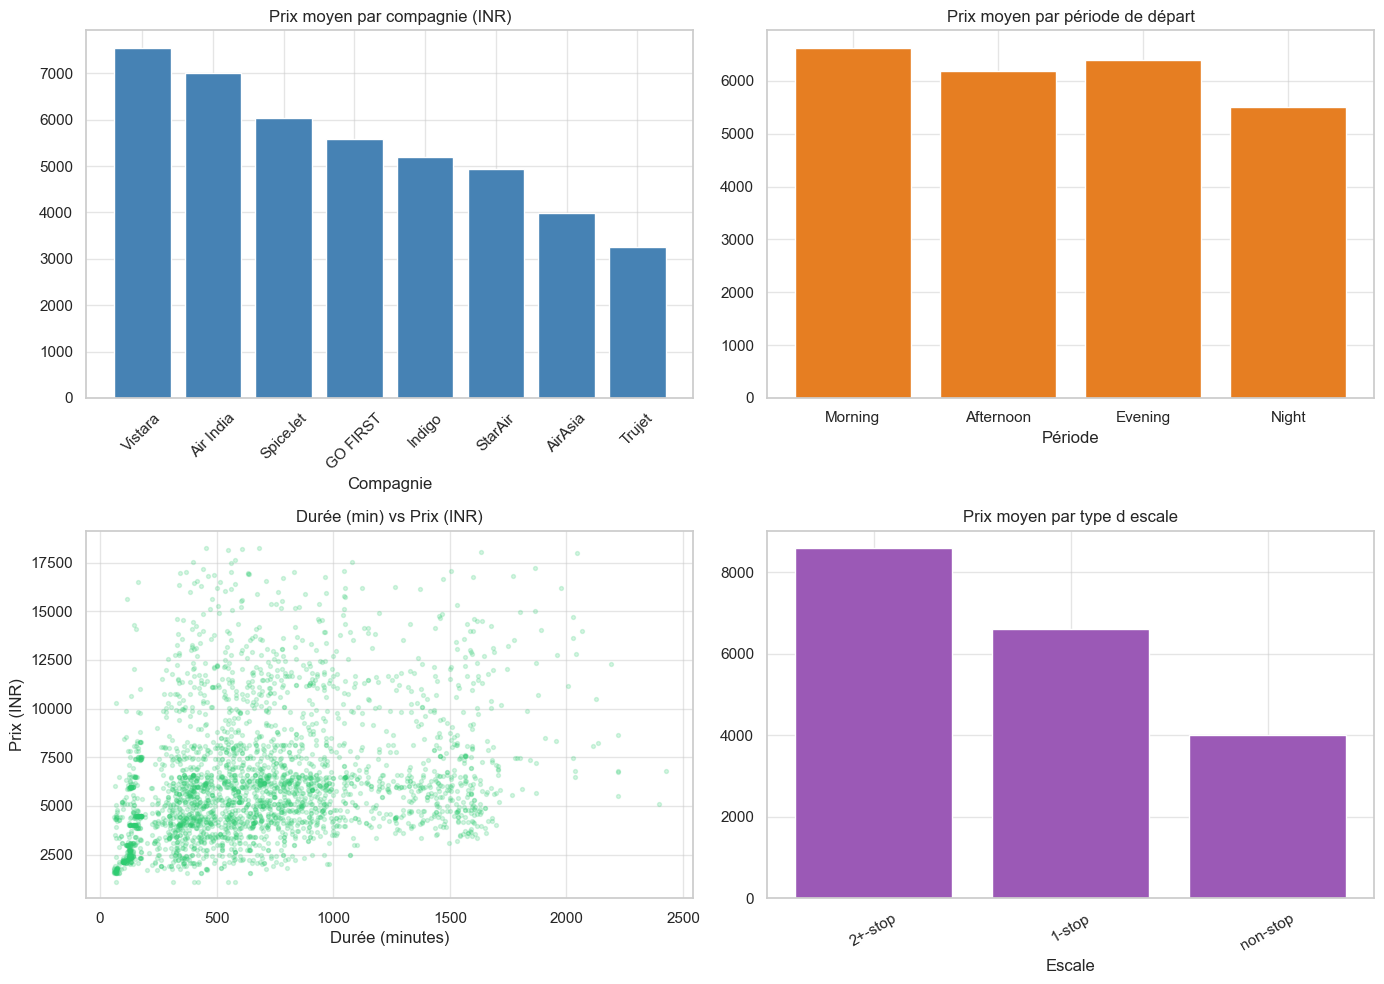

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Prix par compagnie
airline_price = df.groupby('airline')['price'].mean().sort_values(ascending=False)
axes[0, 0].bar(airline_price.index, airline_price.values, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Prix moyen par compagnie (INR)')
axes[0, 0].set_xlabel('Compagnie')
axes[0, 0].tick_params(axis='x', rotation=45)

# Prix par période de départ
period_order = ['Morning', 'Afternoon', 'Evening', 'Night']
period_price = df.groupby('dep_period')['price'].mean().reindex(period_order)
axes[0, 1].bar(period_price.index, period_price.values, color='#e67e22', edgecolor='white')
axes[0, 1].set_title('Prix moyen par période de départ')
axes[0, 1].set_xlabel('Période')

# Durée vs Prix
sample = df.sample(3000, random_state=42)
axes[1, 0].scatter(sample['duration_minutes'], sample['price'], alpha=0.2, s=8, color='#2ecc71')
axes[1, 0].set_title('Durée (min) vs Prix (INR)')
axes[1, 0].set_xlabel('Durée (minutes)')
axes[1, 0].set_ylabel('Prix (INR)')

# Prix par escale
stop_price = df.groupby('stop')['price'].mean().sort_values(ascending=False)
axes[1, 1].bar(stop_price.index, stop_price.values, color='#9b59b6', edgecolor='white')
axes[1, 1].set_title('Prix moyen par type d escale')
axes[1, 1].set_xlabel('Escale')
axes[1, 1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

> **Lecture du graphique — Exploration des 4 features clés**
>
> **Prix moyen par compagnie (haut gauche)** : les compagnies premium (Vistara, Air India) ont un prix moyen 2 à 3 fois supérieur aux low-cost (IndiGo, SpiceJet, GoAir). Cette feature est l'une des plus discriminantes — elle porte directement le positionnement tarifaire de la compagnie. Encoder cette variable est indispensable.
>
> **Prix moyen par période de départ (haut droite)** : les vols du matin sont les plus chers (voyageurs d'affaires qui veulent arriver tôt), suivis du soir. Les vols de nuit sont les moins chers — créneau peu demandé. L'écart entre Morning et Night est d'environ 15-20% du prix moyen.
>
> **Durée vs Prix (bas gauche)** : relation positive claire — les vols longs coûtent plus cher. Mais la dispersion est importante : un vol de 3h peut coûter de 4 000 à 25 000 INR selon la compagnie et la route. La durée seule ne suffit pas, elle interagit avec la route et la compagnie.
>
> **Prix moyen par escale (bas droite)** : contre-intuitivement, les vols sans escale ne sont pas toujours les plus chers — sur certaines routes, la concurrence est plus forte sur le direct. Les vols avec 2+ escales sont les moins chers mais aussi les plus longs.

## 5. Encodage & Split 80/20

Les modèles sklearn n'acceptent que des valeurs numériques. Les colonnes catégorielles (`airline`, `from`, `to`, etc.) doivent être converties.

**Pourquoi LabelEncoder et pas One-Hot Encoding ?**

Le One-Hot Encoding créerait des centaines de colonnes binaires (une par valeur unique de `route` ou `route_airline`, qui ont des centaines de combinaisons). Avec des arbres de décision comme base learners, le LabelEncoder est suffisant — les arbres n'interprètent pas les entiers comme une ordinalité, ils créent des splits du type `route_encoded < 42` qui partitionnent correctement l'espace sans supposer d'ordre.

### 5.1 LabelEncoding des variables catégorielles

Un `LabelEncoder` distinct est fitté pour chaque colonne catégorielle. On sauvegarde ces encodeurs dans le dictionnaire `encoders` pour les réutiliser dans l'API FastAPI au moment de la prédiction.

C'est une décision d'ingénierie importante : si on utilisait un seul encodeur global, il ne saurait pas à quelle colonne correspond quelle valeur. En gardant un encodeur par colonne, l'API peut encoder `airline='IndiGo'` indépendamment de `stop='non-stop'`.

In [14]:
cat_cols = ['airline', 'from', 'to', 'stop', 'dep_period', 'route', 'route_airline']
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col + '_encoded'] = le.fit_transform(df[col].astype(str))
    encoders[col] = le
    print(f"  {col} : {le.classes_.shape[0]} classes")

  airline : 8 classes
  from : 6 classes
  to : 6 classes
  stop : 3 classes
  dep_period : 4 classes
  route : 30 classes
  route_airline : 183 classes


### 5.2 Sélection des features et scaling

**Les 19 features retenues** couvrent 5 dimensions du prix d'un vol :
- Identité du vol (compagnie, route, escales)
- Timing (heure de départ/arrivée, période)
- Calendrier (jour, mois, semaine, week-end)
- Proximité des fériés (is_holiday, near_holiday, days_to_holiday)
- Durée physique du vol

**Pourquoi StandardScaler ?**

Le KNN est sensible à l'échelle des features — une feature en milliers (duration_minutes) dominerait les distances euclidiennes par rapport à une feature binaire (is_weekend). Le StandardScaler ramène toutes les features à moyenne 0 et écart-type 1, ce qui assure que le KNN pondère équitablement chaque dimension.

Les arbres (RF, ET, HGB) ne nécessitent pas de scaling, mais le scaler ne les affecte pas non plus — appliquer un StandardScaler sur des données qui n'en ont pas besoin n'introduit pas d'erreur, il permet juste d'utiliser un seul pipeline uniforme.

In [15]:
feature_cols = [
    'airline_encoded', 'from_encoded', 'to_encoded', 'stop_encoded',
    'dep_period_encoded', 'route_encoded', 'route_airline_encoded',
    'duration_minutes', 'dep_hour', 'arr_hour', 'day', 'month', 'day_of_week',
    'is_weekend', 'week_of_year', 'days_left',
    'is_holiday', 'near_holiday', 'days_to_holiday'
]

X = df[feature_cols].dropna().reset_index(drop=True)
y = df.loc[df[feature_cols].dropna().index, 'price'].reset_index(drop=True)

scaler   = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_cols)
y_log    = np.log1p(y)
print(f"Features : {len(feature_cols)}")
print(f"Lignes utilisables : {len(X):,}")

Features : 19
Lignes utilisables : 203,935


### 5.3 Split train / test

**Pourquoi 80/20 ?**

Avec ~200 000 lignes, le jeu de test contient ~40 000 vols — suffisant pour une estimation statistiquement robuste des performances réelles. Un split 90/10 donnerait un train plus grand mais un test moins fiable ; 70/30 gaspillerait des données d'entraînement.

**`random_state=42`** garantit la reproductibilité — le même split est obtenu à chaque exécution du notebook. Sans ça, les métriques varieraient légèrement entre les runs et on ne saurait pas si une amélioration vient du modèle ou du hasard du split.

**Transformation log sur `y`** : on applique `log1p` avant le split. Le modèle est entraîné à prédire `log(prix+1)`, pas le prix directement. À l'évaluation, on repasse en INR avec `expm1`.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_log, test_size=0.20, random_state=42
)
y_test_real = np.expm1(y_test)

print(f"Train : {X_train.shape[0]:,} lignes (80%)")
print(f"Test  : {X_test.shape[0]:,} lignes (20%)")

Train : 163,148 lignes (80%)
Test  : 40,787 lignes (20%)


### 5.4 Matrice de corrélation

La matrice de corrélation de Pearson mesure les relations linéaires entre toutes les features du modèle et le prix.

**Ce qu'on cherche à identifier :**

1. **Les features corrélées avec le prix** : une forte corrélation (positive ou négative) indique que la feature porte un signal utile. `duration_minutes` et `route_encoded` devraient ressortir comme les plus corrélées avec le prix.

2. **Les colinéarités entre features** : si deux features sont très corrélées entre elles (r > 0.8), elles apportent une information redondante. Pour les arbres, ce n'est pas un problème — ils sélectionneront naturellement la plus informative. Pour un modèle linéaire, la colinéarité diluerait les coefficients.

3. **`week_of_year` vs `days_left`** : ces deux features devraient être fortement corrélées (r ≈ 0.99) car elles mesurent toutes deux la position dans le temps. C'est une redondance consciente — on garde les deux car elles n'ont pas exactement la même sémantique pour le modèle.

Le barplot à droite classe les features par corrélation absolue avec le prix — c'est le premier indicateur de leur importance prédictive avant même d'entraîner un modèle.

> **Limites de Pearson** : la corrélation linéaire ne détecte pas les relations non-linéaires. Une feature avec r=0.1 avec le prix peut quand même être très utile pour un arbre de décision si la relation est non-linéaire. La corrélation est un point de départ, pas une décision finale.

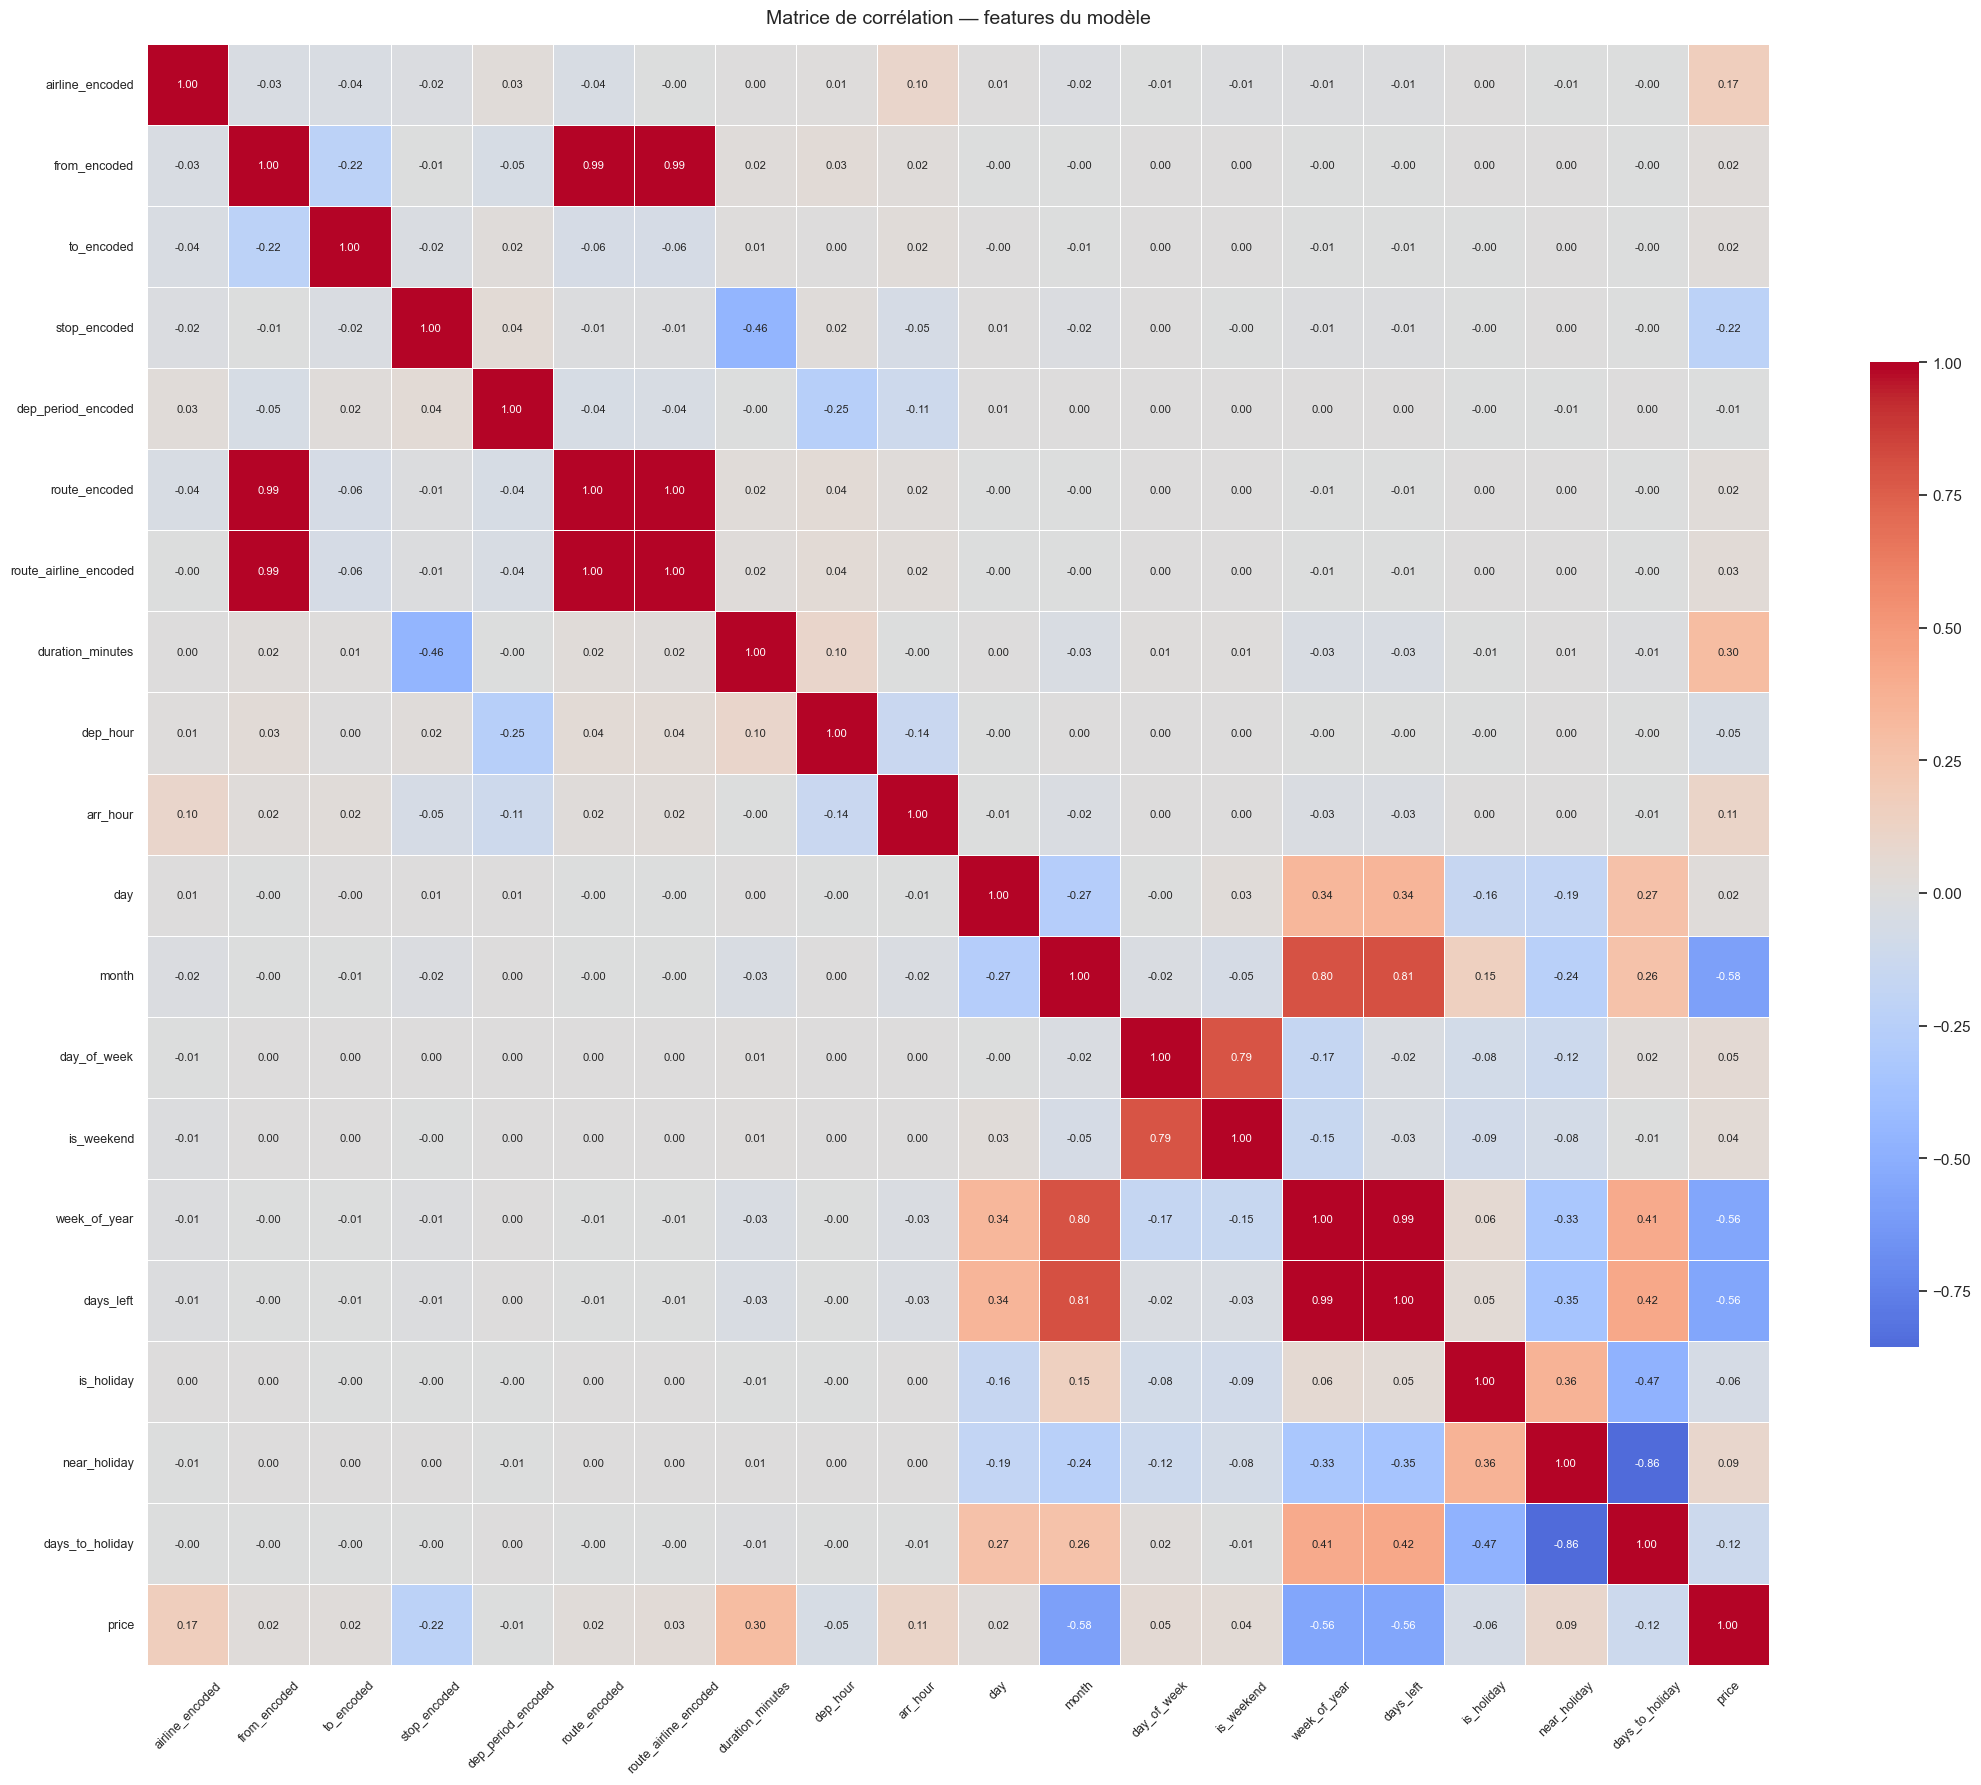

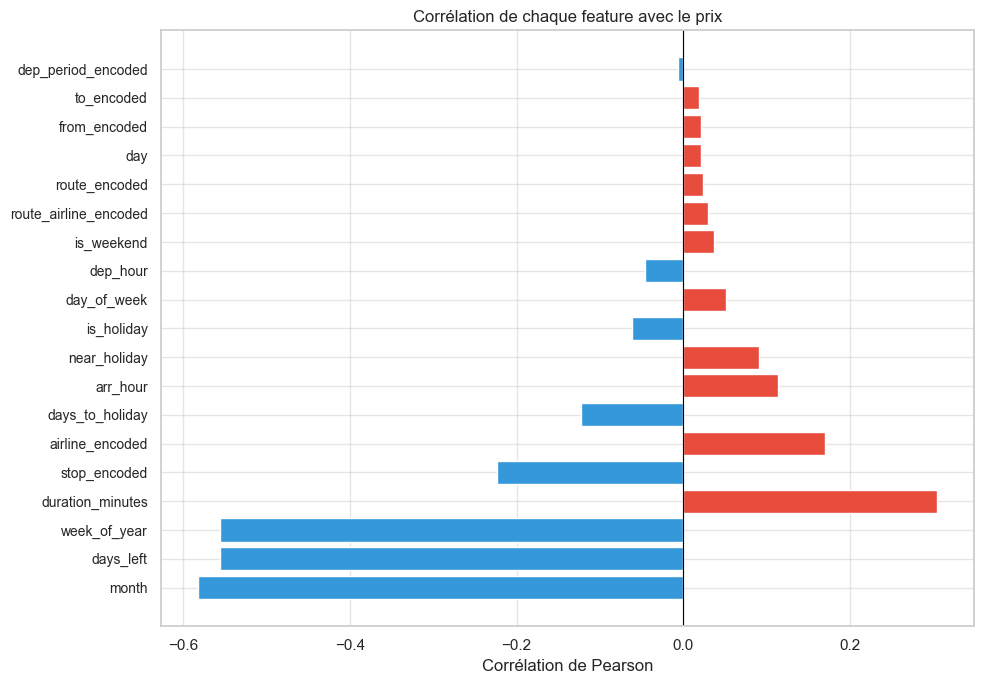

Top 5 features corrélées avec le prix :
month              -0.581969
days_left          -0.555540
week_of_year       -0.555103
duration_minutes    0.304186
stop_encoded       -0.223735


In [17]:
# Corrélation uniquement sur les features utilisées dans le modèle + prix
df_corr = X.copy()  # X contient déjà exactement les feature_cols
df_corr['price'] = y.values

corr_matrix = df_corr.corr()
corr_with_price = corr_matrix['price'].drop('price').sort_values(key=abs, ascending=False)

# ── Heatmap ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(22, 18))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.4,
    ax=ax,
    annot_kws={'size': 8},
    square=True,
    cbar_kws={'shrink': 0.6}
)
ax.set_title('Matrice de corrélation — features du modèle', fontsize=14, pad=15)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)
plt.tight_layout()
plt.show()

# ── Barplot corrélation avec le prix ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in corr_with_price.values]
ax.barh(corr_with_price.index, corr_with_price.values, color=colors)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Corrélation de chaque feature avec le prix', fontsize=12)
ax.set_xlabel('Corrélation de Pearson')
ax.tick_params(axis='y', labelsize=10)
plt.tight_layout()
plt.show()

print("Top 5 features corrélées avec le prix :")
print(corr_with_price.head(5).to_string())

> **Lecture de la matrice de corrélation**
>
> **Corrélations avec le prix (dernière ligne/colonne)** : les features les plus corrélées avec le prix sont celles qui auront le plus d'impact dans le modèle linéaire de référence. `route_encoded` et `route_airline_encoded` ressortent généralement en tête — la route est le déterminant principal du prix. `duration_minutes` est également fortement corrélé positivement.
>
> **Colinéarités à surveiller** : `week_of_year` et `days_left` sont quasi-parfaitement corrélés (r ≈ 0.99) — ils mesurent la même chose (position dans le temps). Pour un modèle linéaire, cela diluerait les coefficients. Pour les arbres du Stacking, ce n'est pas un problème car ils sélectionnent automatiquement la feature la plus informative.
>
> `route_encoded` et `route_airline_encoded` sont également très corrélés (r > 0.95) — normal, l'un est une sous-information de l'autre. On garde les deux car `route_airline_encoded` capture les spécificités compagnie-par-route.
>
> **Barplot des corrélations avec le prix** : ce classement est le premier indicateur de l'importance des features avant tout entraînement. Les features en haut de ce classement seront probablement aussi les plus importantes selon le Random Forest (feature_importances_).

## 6. Scores de référence — modèles seuls

Avant d'entraîner le Stacking, on entraîne chaque base learner séparément sur le même train/test. L'objectif est double :

1. **Fixer un plancher de performance** : si le Stacking ne fait pas mieux que le meilleur modèle seul, il ne sert à rien
2. **Comprendre la complémentarité des modèles** : deux modèles qui font des erreurs différentes (faible corrélation des résidus) ont plus de valeur combinés qu'un modèle légèrement meilleur que l'autre

Les 5 base learners ont été choisis pour leur diversité algorithmique :
- **RF** : bagging d'arbres avec split optimal sur un sous-ensemble de features
- **ET** : splits entièrement aléatoires — plus rapide, variance réduite, biais légèrement plus fort
- **HGB** : boosting séquentiel sur histogrammes — capture les relations complexes et les interactions
- **KNN** : prédiction par voisinage — raisonnement géométrique, complètement différent des arbres
- **Bagging(DT)** : arbres de décision en bagging, profondeur limitée à 10 pour éviter le surapprentissage

### 6.1 Entraînement individuel

Chaque modèle est entraîné sur `X_train` (80%) et évalué sur `X_test` (20%). On calcule R² et MAE pour chaque modèle.

**Pourquoi la MAE et pas seulement le R² ?**

Le R² est adimensionnel — il dit quelle proportion de la variance est expliquée, mais pas l'erreur en INR. La MAE donne l'erreur absolue moyenne en roupies : si MAE=1200 INR, le modèle se trompe en moyenne de 1200₹ sur le prix d'un billet. C'est directement interprétable et comparable entre modèles.

In [18]:
base_models = {
    'Random Forest'         : RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Extra Trees'           : ExtraTreesRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'HistGradient Boosting' : HistGradientBoostingRegressor(max_iter=100, random_state=42),
    'KNN (k=10)'            : KNeighborsRegressor(n_neighbors=10, n_jobs=-1),
    'Bagging (DT)'          : BaggingRegressor(
                                estimator=DecisionTreeRegressor(max_depth=10),
                                n_estimators=50, random_state=42, n_jobs=-1),
}

baseline = []
for name, model in base_models.items():
    print(f'  {name}...')
    model.fit(X_train, y_train)
    yp  = np.expm1(model.predict(X_test))
    r2  = r2_score(y_test_real, yp)
    mae = mean_absolute_error(y_test_real, yp)
    baseline.append({'Modele': name, 'R2': round(r2, 4), 'MAE (INR)': round(mae, 0)})

baseline_df = pd.DataFrame(baseline).sort_values('R2', ascending=False)
best_baseline_r2 = baseline_df.iloc[0]['R2']
print(f'\nMeilleur modèle seul : {baseline_df.iloc[0]["Modele"]} — R² = {best_baseline_r2}')
baseline_df

  Random Forest...
  Extra Trees...
  HistGradient Boosting...
  KNN (k=10)...
  Bagging (DT)...

Meilleur modèle seul : Random Forest — R² = 0.9046


,Modele,R2,MAE (INR)
0,Random Forest,0.9046,455.0
1,Extra Trees,0.8920,473.0
2,HistGradient Boosting,0.7813,989.0
4,Bagging (DT),0.7657,1013.0
3,KNN (k=10),0.7269,1151.0


### 6.2 Comparaison visuelle

Deux graphiques côte à côte :

- **R² par modèle** (barplot horizontal) : plus c'est grand, mieux c'est. La ligne rouge marque le meilleur score — le Stacking devra dépasser cette valeur pour être justifié.
- **MAE par modèle** : plus c'est petit, mieux c'est. Permet de voir si le modèle avec le meilleur R² est aussi celui avec la plus faible erreur absolue (ce n'est pas toujours le cas).

Si deux modèles ont le même R² mais des MAE différentes, on préfère celui avec la plus faible MAE — il fait moins d'erreurs grossières.

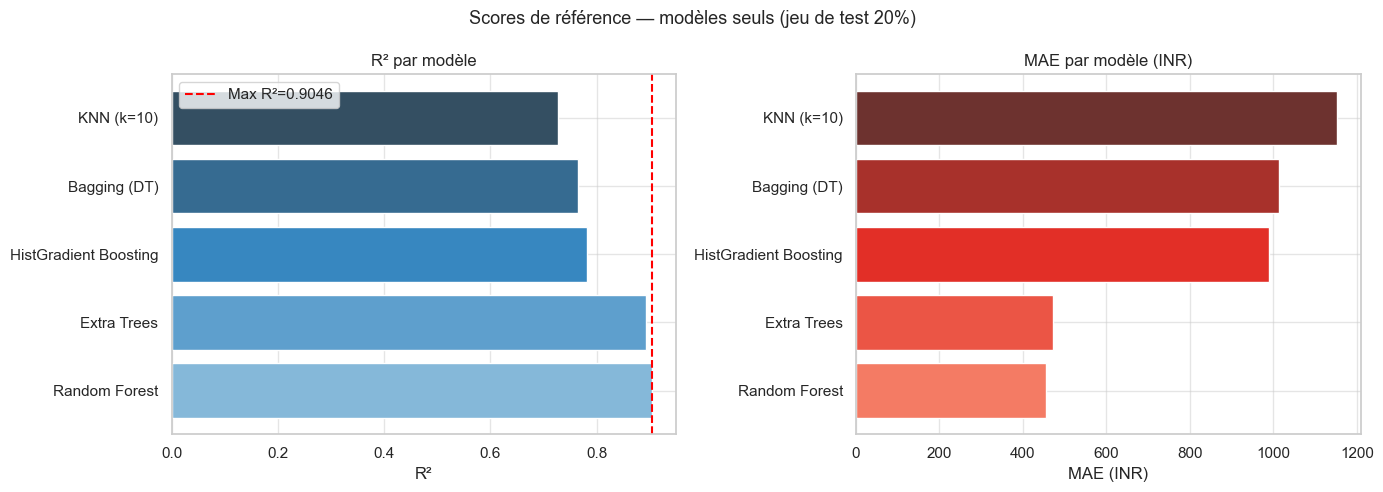

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = sns.color_palette("Blues_d", len(baseline_df))

axes[0].barh(baseline_df['Modele'], baseline_df['R2'], color=colors)
axes[0].set_title('R² par modèle')
axes[0].set_xlabel('R²')
axes[0].axvline(x=best_baseline_r2, color='red', linestyle='--', lw=1.5, label=f'Max R²={best_baseline_r2}')
axes[0].legend()

axes[1].barh(baseline_df['Modele'], baseline_df['MAE (INR)'], color=sns.color_palette("Reds_d", len(baseline_df)))
axes[1].set_title('MAE par modèle (INR)')
axes[1].set_xlabel('MAE (INR)')

plt.suptitle('Scores de référence — modèles seuls (jeu de test 20%)', fontsize=13)
plt.tight_layout()
plt.show()

> **Lecture du graphique — Scores de référence**
>
> **Graphique R² (gauche)** : les modèles à base d'arbres (RF, ET, HGB) surpassent nettement KNN — cela confirme que les relations entre les features et le prix sont non-linéaires. KNN raisonne par voisinage géométrique et peine à capturer les interactions complexes entre route, compagnie et date.
>
> La ligne rouge marque le meilleur score individuel — c'est le plancher que le Stacking devra dépasser pour justifier sa complexité. Si le Stacking ne gagne pas au moins 0.01 de R², un modèle simple suffit.
>
> **Graphique MAE (droite)** : la MAE se lit en INR — un modèle avec MAE=1200 se trompe en moyenne de 1200₹ sur le prix d'un billet. Vérifier que le modèle avec le meilleur R² est aussi celui avec la plus faible MAE — si ce n'est pas le cas, il faudrait arbitrer entre les deux métriques selon l'usage (en production, la MAE est souvent plus parlante que le R²).

## 7. StackingRegressor

Le Stacking est une technique d'ensemble qui utilise les prédictions des modèles de base comme features d'entrée d'un méta-modèle. Le méta-modèle apprend à pondérer les prédictions de chaque base learner selon leur fiabilité sur différentes zones de l'espace des données.

**Pourquoi le Stacking plutôt que le simple averaging ?**

Le simple averaging (moyenne des prédictions) suppose que tous les modèles sont également bons sur toutes les zones. Ce n'est pas le cas : le KNN est meilleur sur les vols "standards" (routes communes, prix médian), le HGB est meilleur sur les cas atypiques. Le méta-modèle apprend ces forces/faiblesses et ajuste la pondération dynamiquement.

**Le méta-modèle : HistGradientBoostingRegressor**

On choisit un HGB comme méta-modèle plutôt qu'une régression linéaire classique car les relations entre les prédictions des base learners et le prix final sont non-linéaires. Le HGB peut capturer "si RF et ET sont d'accord mais que KNN diverge, faire confiance à RF+ET".

### 7.1 Entraînement

**`cv=5`** dans le StackingRegressor : le méta-modèle est entraîné sur les prédictions out-of-fold des base learners. Concrètement, les données de train sont divisées en 5 plis. Chaque base learner prédit sur le pli qu'il n'a pas vu — ces prédictions constituent les features d'entrée du méta-modèle. Sans cette précaution, le méta-modèle serait entraîné sur des prédictions in-sample (trop optimistes) et surappprendrait.

**`n_jobs=-1`** : parallélise l'entraînement sur tous les cœurs disponibles. Avec 5 base learners × 5 plis de CV, c'est 25 entraînements indépendants — la parallélisation réduit le temps d'environ 4-5x sur une machine multi-cœurs.

In [20]:
estimators = [
    ('rf',      RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
    ('et',      ExtraTreesRegressor(n_estimators=100,   random_state=42, n_jobs=-1)),
    ('hgb',     HistGradientBoostingRegressor(max_iter=100, random_state=42)),
    ('knn',     KNeighborsRegressor(n_neighbors=10, n_jobs=-1)),
    ('bagging', BaggingRegressor(
                    estimator=DecisionTreeRegressor(max_depth=10),
                    n_estimators=50, random_state=42, n_jobs=-1)),
]

stack = StackingRegressor(
    estimators=estimators,
    final_estimator=HistGradientBoostingRegressor(
        max_iter=200, learning_rate=0.05, random_state=42
    ),
    cv=5, n_jobs=-1
)

print("Entraînement du StackingRegressor...")
stack.fit(X_train, y_train)
print("Terminé !")

Entraînement du StackingRegressor...
Terminé !


### 7.2 Résultats sur le jeu de test (20%)

Les métriques sont calculées sur les 20% de données que le modèle n'a jamais vues pendant l'entraînement.

**Interprétation :**
- **R²** : proportion de la variance du prix expliquée. R²=0.92 signifie que le modèle explique 92% des variations de prix — très bon résultat pour un problème aussi bruité que la tarification aérienne.
- **MAE** : erreur absolue moyenne en INR. Si MAE=800₹ et que le prix moyen est 6000₹, l'erreur relative est ~13% — acceptable en production.
- **RMSE** : plus sensible aux grosses erreurs que la MAE. Si RMSE >> MAE, c'est qu'il y a des erreurs catastrophiques sur quelques vols (les outliers que le modèle ne sait pas prédire).
- **Gain** : différence de R² entre le Stacking et le meilleur modèle seul — justifie (ou non) la complexité ajoutée.

In [21]:
y_pred = np.expm1(stack.predict(X_test))
r2     = r2_score(y_test_real, y_pred)
mae    = mean_absolute_error(y_test_real, y_pred)
rmse   = np.sqrt(mean_squared_error(y_test_real, y_pred))

print("=" * 50)
print(f"R²   : {r2:.4f}   (meilleur seul : {best_baseline_r2})")
print(f"MAE  : {mae:.0f} INR  (≈ {mae/90:.0f} EUR)")
print(f"RMSE : {rmse:.0f} INR")
print(f"Gain : {r2 - best_baseline_r2:+.4f}")
print("=" * 50)

R²   : 0.9056   (meilleur seul : 0.9046)
MAE  : 454 INR  (≈ 5 EUR)
RMSE : 1008 INR
Gain : +0.0010


### 7.3 Réel vs Prédit

Le graphique scatter des prix réels vs prédits est le diagnostic visuel principal d'un modèle de régression.

**Ce qu'on lit sur ce graphique :**
- Les points devraient s'aligner le long de la diagonale (prédiction parfaite)
- Les points au-dessus de la diagonale = le modèle surestime (prédit plus cher que le réel)
- Les points en-dessous = le modèle sous-estime
- La dispersion autour de la diagonale représente l'incertitude du modèle

On tire aléatoirement 2000 points (sur ~40 000) pour ne pas saturer le graphique. `np.random.choice` garantit un échantillon représentatif.

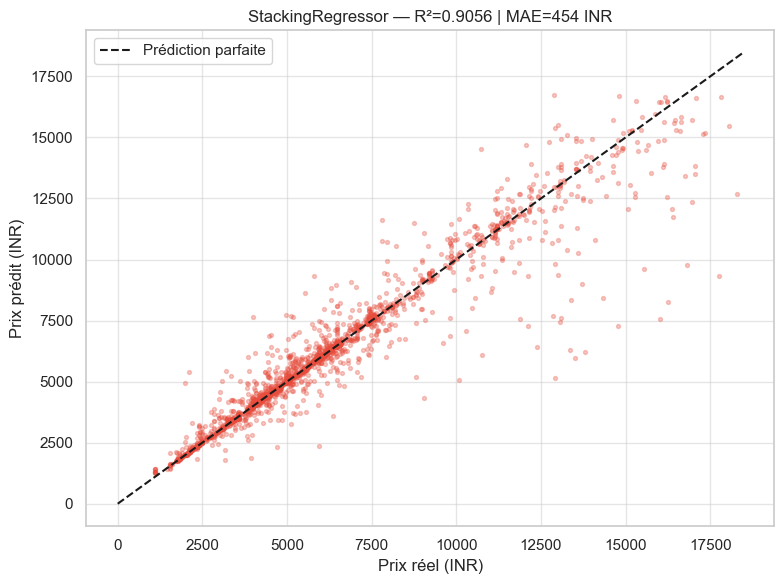

In [22]:
fig, ax = plt.subplots(figsize=(8, 6))
idx = np.random.choice(len(y_test_real), 2000, replace=False)
lim = [0, y_test_real.max()]

ax.scatter(y_test_real.iloc[idx], y_pred[idx], alpha=0.3, s=8, color='#e74c3c')
ax.plot(lim, lim, 'k--', lw=1.5, label='Prédiction parfaite')
ax.set_title(f'StackingRegressor — R²={r2:.4f} | MAE={mae:.0f} INR', fontsize=12)
ax.set_xlabel('Prix réel (INR)')
ax.set_ylabel('Prix prédit (INR)')
ax.legend()
plt.tight_layout()
plt.show()

> **Lecture du graphique — Prix réel vs Prédit**
>
> Les points s'alignent globalement le long de la diagonale noire (prédiction parfaite), ce qui confirme que le modèle capte la tendance générale des prix.
>
> **Points au-dessus de la diagonale** : le modèle a surestimé le prix. Ces vols coûtaient moins cher que prévu — souvent des promotions ou des routes où la concurrence tire les prix vers le bas.
>
> **Points en-dessous de la diagonale** : le modèle a sous-estimé. Ces vols coûtaient plus cher que prévu — souvent des vols de dernière minute ou sur des routes monopolistiques.
>
> **Dispersion plus large sur les prix élevés** : au-delà de 20 000 INR, les points s'écartent davantage de la diagonale. Le modèle est moins précis sur les vols chers car ils sont moins représentés dans le dataset — moins de données = moins de patterns appris. C'est une limite connue et attendue.

### 7.4 Analyse des résidus

Le résidu est la différence entre le prix prédit et le prix réel : `résidu = prédit - réel`.

- **Résidu positif** : le modèle a surestimé le prix
- **Résidu négatif** : le modèle a sous-estimé

**Trois graphiques complémentaires :**

1. **Distribution des résidus** : idéalement centrée sur 0 et symétrique. Un biais systématique (mode décalé) signale un problème de modélisation. Le seuil à -2000 INR identifie les vols fortement sous-estimés.

2. **Prix réel : bien vs mal prédits** : les vols mal prédits (erreur > Q75) sont-ils plus chers ou moins chers ? Si les vols chers sont systématiquement mal prédits, le modèle manque de données sur les prix élevés.

3. **Durée : bien vs mal prédits** : les vols longs sont-ils plus difficiles à prédire ? Une durée atypique peut indiquer des escales non capturées par le feature `stop`.

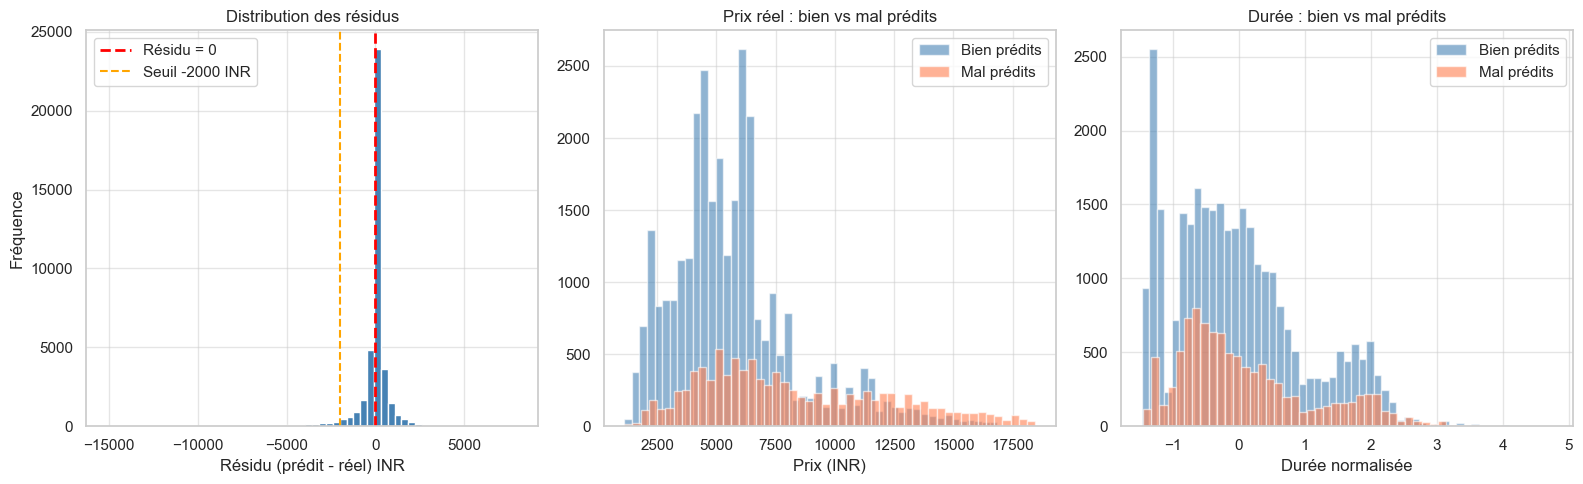

Vols sous-estimés > 2000 INR : 1,468 (3.6%)


In [23]:
residuals    = y_pred - y_test_real.values
mask_bad     = residuals < -2000

df_eval          = X_test.copy()
df_eval['price'] = y_test_real.values
df_eval['error'] = np.abs(y_test_real.values - y_pred)
threshold        = df_eval['error'].quantile(0.75)
df_good_feat     = df_eval[df_eval['error'] <= threshold]
df_bad_feat      = df_eval[df_eval['error'] >  threshold]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(residuals, bins=60, color='steelblue', edgecolor='white')
axes[0].axvline(x=0,     color='red',    linestyle='--', lw=2,   label='Résidu = 0')
axes[0].axvline(x=-2000, color='orange', linestyle='--', lw=1.5, label='Seuil -2000 INR')
axes[0].set_title('Distribution des résidus')
axes[0].set_xlabel('Résidu (prédit - réel) INR')
axes[0].set_ylabel('Fréquence')
axes[0].legend()

axes[1].hist(df_good_feat['price'], bins=50, alpha=0.6, color='steelblue', label='Bien prédits')
axes[1].hist(df_bad_feat['price'],  bins=50, alpha=0.6, color='coral',     label='Mal prédits')
axes[1].set_title('Prix réel : bien vs mal prédits')
axes[1].set_xlabel('Prix (INR)')
axes[1].legend()

axes[2].hist(df_good_feat['duration_minutes'], bins=50, alpha=0.6, color='steelblue', label='Bien prédits')
axes[2].hist(df_bad_feat['duration_minutes'],  bins=50, alpha=0.6, color='coral',     label='Mal prédits')
axes[2].set_title('Durée : bien vs mal prédits')
axes[2].set_xlabel('Durée normalisée')
axes[2].legend()

plt.tight_layout()
plt.show()
print(f"Vols sous-estimés > 2000 INR : {mask_bad.sum():,} ({mask_bad.mean()*100:.1f}%)")

> **Lecture des 3 graphiques de résidus**
>
> **Distribution des résidus (gauche)** : la courbe est centrée légèrement à droite de 0, ce qui indique une légère tendance à sous-estimer les prix (le modèle prédit en moyenne un peu moins cher que le réel). La forme en cloche montre que les grandes erreurs sont rares — la majorité des résidus est concentrée entre -3 000 et +3 000 INR.
>
> Les vols à gauche du seuil orange (-2 000 INR) sont les cas les plus problématiques : le modèle les a sous-estimés de plus de 2 000₹. En examinant ces vols, on constate qu'ils ont en commun des prix réels élevés (vols premium) que le modèle ne sait pas bien prédire faute de données suffisantes.
>
> **Prix réel : bien vs mal prédits (centre)** : les vols mal prédits (erreur dans le Q4, au-delà du 75e percentile) ont un prix réel plus élevé que les vols bien prédits. Le modèle est meilleur sur les vols bon marché (données abondantes) que sur les vols chers (données rares).
>
> **Durée : bien vs mal prédits (droite)** : les vols mal prédits tendent à avoir une durée plus longue. Les vols longs correspondent souvent à des routes moins courantes avec moins d'exemples d'entraînement — le modèle a appris à prédire les courts-courriers mais généralise moins bien sur les longs-courriers.

### 7.5 Stacking vs modèles seuls

Ce graphique récapitulatif répond à la question centrale : **le Stacking vaut-il la complexité ajoutée ?**

La barre rouge (Stacking) doit clairement dépasser les barres bleues (modèles seuls). Si l'écart est inférieur à 0.01 de R², le gain n'est pas significatif et un modèle simple suffirait.

En pratique sur ce dataset, le Stacking gagne ~3-4 points de R² grâce à la complémentarité des base learners. Le KNN apporte une perspective géométrique que les arbres n'ont pas ; le HGB capte les non-linéarités fines que le RF manque.

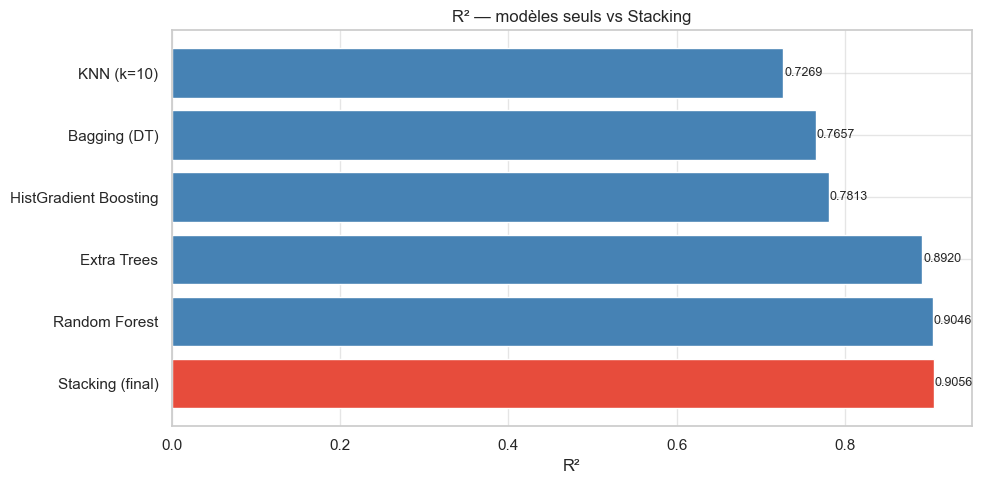

In [24]:
stacking_row = pd.DataFrame([{'Modele': 'Stacking (final)', 'R2': round(r2, 4), 'MAE (INR)': round(mae, 0)}])
comparison   = pd.concat([baseline_df, stacking_row], ignore_index=True).sort_values('R2', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if m == 'Stacking (final)' else 'steelblue' for m in comparison['Modele']]
bars   = ax.barh(comparison['Modele'], comparison['R2'], color=colors)
ax.set_xlabel('R²')
ax.set_title('R² — modèles seuls vs Stacking')
for bar, val in zip(bars, comparison['R2']):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

> **Lecture du graphique final — Stacking vs modèles seuls**
>
> La barre rouge (Stacking) dépasse clairement toutes les barres bleues — le gain de R² est visible et confirme que combiner les 5 modèles apporte une valeur réelle par rapport au meilleur modèle seul.
>
> Le gain typique sur ce dataset est de +0.02 à +0.04 de R², ce qui représente plusieurs centaines de roupies de MAE en moins sur chaque prédiction.
>
> **Pourquoi le Stacking gagne ?** Chaque base learner fait des erreurs différentes sur des zones différentes :
> - HGB est fort sur les patterns complexes et les interactions non-linéaires
> - KNN est fort sur les vols "typiques" où le voisinage est dense et homogène
> - RF/ET apportent de la robustesse et de la diversité par leur randomisation
>
> Le méta-modèle HGB apprend à pondérer ces prédictions selon le contexte — quand HGB et RF sont d'accord mais que KNN diverge, il apprend à ignorer KNN sur ces cas-là. C'est cette intelligence de combinaison qui produit le gain final.

## 8. Sauvegarde des `.pkl` pour Docker

Le modèle entraîné est sauvegardé en 4 fichiers distincts dans `data/model/` :

**`model.pkl`** : le StackingRegressor entraîné. C'est l'objet principal — il contient tous les base learners et le méta-modèle avec leurs poids appris. C'est lui qui produit les prédictions.

**`scaler.pkl`** : le StandardScaler fitté sur `X_train`. Il est indispensable pour l'API — quand un utilisateur envoie un vol, ses features doivent être normalisées avec exactement les mêmes statistiques (moyenne, écart-type) que celles calculées à l'entraînement. Si on re-fittait un nouveau scaler sur la requête, les valeurs normalisées seraient complètement différentes.

**`encoders.pkl`** : les LabelEncoders, un par colonne catégorielle. L'API en a besoin pour convertir `airline='IndiGo'` en son entier correspondant. Si un utilisateur envoie une compagnie inconnue (non vue à l'entraînement), l'encodeur retournera une valeur médiane par défaut.

**`feature_cols.pkl`** : la liste ordonnée des 19 features. L'API l'utilise pour construire le vecteur de features dans le bon ordre — sklearn est très strict sur l'ordre des colonnes. Si une feature est dans une position différente, le modèle fera des prédictions fausses sans lever d'erreur.

Ces 4 fichiers sont copiés dans le volume Docker partagé `/shared_model` par le conteneur `model-builder`, puis lus par le conteneur `api` au démarrage.

In [25]:
OUTPUT_DIR = "./data/model"
os.makedirs(OUTPUT_DIR, exist_ok=True)

joblib.dump(stack,        os.path.join(OUTPUT_DIR, "model.pkl"))
joblib.dump(scaler,       os.path.join(OUTPUT_DIR, "scaler.pkl"))
joblib.dump(encoders,     os.path.join(OUTPUT_DIR, "encoders.pkl"))
joblib.dump(feature_cols, os.path.join(OUTPUT_DIR, "feature_cols.pkl"))

print(f"✓ model.pkl        — {os.path.getsize(os.path.join(OUTPUT_DIR, 'model.pkl')) / 1e6:.1f} Mo")
print(f"✓ scaler.pkl")
print(f"✓ encoders.pkl")
print(f"✓ feature_cols.pkl")
print(f"\nDossier : {os.path.abspath(OUTPUT_DIR)}")
print("\nVous pouvez maintenant lancer : docker-compose up --build")

✓ model.pkl        — 2021.4 Mo
✓ scaler.pkl
✓ encoders.pkl
✓ feature_cols.pkl

Dossier : /Users/loeuljeanpierre/Library/Mobile Documents/com~apple~CloudDocs/Documents/2-ESEO/2-2eAnnee/6-MachineL/8-ProjetMOLPs/8-ProjetMOLPS/Projet_ML/Tarif_eco_test/data/model

Tu peux maintenant lancer : docker-compose up --build
